In [1]:
from os import environ
environ["CUDA_VISIBLE_DEVICES"] = "1"
environ["OMP_NUM_THREADS"] = "16"
environ["MAX_JOBS"] = "16"
environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
def seed_everything(seed: int = 137) -> None:
    random.seed(seed)
    np.random.seed(seed)

SEED = 137
seed_everything(seed = SEED)

In [15]:
cuda_data = pd.read_csv(
    r"./out/cuda_gsddmm/all_datasets_cuda_gsddmm.csv",
    header=0, memory_map=True, low_memory=False,
    usecols=["backend", "conv_type", "dataset", "num_nodes", "num_edges", "feature_dim", "ms_per_iter", "dtype", "aggr", "mode", "iters"]
)

is_edge = cuda_data["conv_type"].apply(lambda x: x[-5:] == "_edge")
cuda_data["backend"] = cuda_data["backend"] + is_edge.apply(lambda x: "_edge" if x else "")
cuda_data["conv_type"] = cuda_data["conv_type"].apply(lambda x: x[:-5] if x[-5:] == "_edge" else x)

cuda_data.dropna(how="any", inplace=True)
cuda_data

,backend,conv_type,dataset,num_nodes,num_edges,feature_dim,dtype,aggr,mode,iters,ms_per_iter
0,cuda,u_add_v,amazon-computers,13752,505474,256,fp32,True,forward,20,0.557824
1,cuda,v_add_u,amazon-computers,13752,505474,256,fp32,True,forward,20,0.558438
2,cuda,u_add_e,amazon-computers,13752,505474,256,fp32,True,forward,20,0.842240
3,cuda,e_add_u,amazon-computers,13752,505474,256,fp32,True,forward,20,0.853709
4,cuda,v_add_e,amazon-computers,13752,505474,256,fp32,True,forward,20,0.714803
...,...,...,...,...,...,...,...,...,...,...,...
4795,cuda_edge,e_dot_u,WikiCS,11701,443427,256,bf16,True,forward,20,0.338278
4796,cuda_edge,v_dot_e,WikiCS,11701,443427,256,bf16,True,forward,20,0.338176
4797,cuda_edge,e_dot_v,WikiCS,11701,443427,256,bf16,True,forward,20,0.338074
4798,cuda_edge,copy_u,WikiCS,11701,443427,256,bf16,True,forward,20,0.339302


In [16]:
dgl_data = pd.read_csv(
    r"./out/dgl_gsddmm/all_datasets_dgl_ops.csv",
    header=0, memory_map=True, low_memory=False,
    usecols=["backend", "conv_type", "dataset", "num_nodes", "num_edges", "feature_dim", "ms_per_iter", "dtype", "aggr", "mode", "iters"]
)
dgl_data = dgl_data[dgl_data["conv_type"].isin(set(cuda_data.conv_type.unique()))]
dgl_data = dgl_data[dgl_data["mode"] == "forward"]

dgl_data.dropna(how="any", inplace=True)
dgl_data

,backend,conv_type,dataset,num_nodes,num_edges,feature_dim,dtype,aggr,mode,iters,ms_per_iter
0,dgl,copy_u,amazon-computers,13752,505474,256,fp32,True,forward,20,0.732723
1,dgl,copy_v,amazon-computers,13752,505474,256,fp32,True,forward,20,0.785050
11,dgl,u_add_v,amazon-computers,13752,505474,256,fp32,True,forward,20,0.822835
12,dgl,u_add_e,amazon-computers,13752,505474,256,fp32,True,forward,20,0.903168
13,dgl,v_add_u,amazon-computers,13752,505474,256,fp32,True,forward,20,0.820634
...,...,...,...,...,...,...,...,...,...,...,...
7530,dgl,u_dot_e,WikiCS,11701,443427,256,bf16,True,forward,20,0.325581
7531,dgl,v_dot_u,WikiCS,11701,443427,256,bf16,True,forward,20,0.270285
7532,dgl,v_dot_e,WikiCS,11701,443427,256,bf16,True,forward,20,0.325018
7533,dgl,e_dot_u,WikiCS,11701,443427,256,bf16,True,forward,20,0.325274


In [28]:
all_data = pd.concat([cuda_data, dgl_data], axis=0)

dataset_set = set(cuda_data.dataset.unique()) & (set(dgl_data.dataset.unique()))

all_data = all_data[all_data['dataset'].isin(dataset_set)]

In [30]:
GROUP_KEYS = ["conv_type", "dataset", "dtype", "mode"]

# median ms_per_iter per (group, backend)
pivot = all_data.pivot_table(
    index=GROUP_KEYS,
    columns="backend",
    values="ms_per_iter",
    aggfunc="median",
)

# highest feature_dim each backend managed to run per group
# (a backend that OOM'ed is simply absent from the feature_dims it couldn't run)
max_fdim = all_data.pivot_table(
    index=GROUP_KEYS,
    columns="backend",
    values="feature_dim",
    aggfunc="max",
)

# normal ratio: backend ms / dgl ms (< 1 = faster than dgl)
ratio_0 = pivot["dgl"].div(pivot['cuda'], axis=0).drop(columns="dgl")
ratio_1 = pivot["dgl"].div(pivot['cuda_edge'], axis=0).drop(columns="dgl")
ratio = pd.concat([ratio_0, ratio_1], axis=1)

backend_fdim = max_fdim.reindex(columns=ratio.columns)
better = backend_fdim.gt(max_fdim["dgl"], axis=0)  # backend survived a feature_dim dgl couldn't
worse = backend_fdim.lt(max_fdim["dgl"], axis=0)   # backend OOM'ed before dgl did

ratio = (
    ratio
    .mask(better, 0.0)    # infinitely better
    .mask(worse, np.inf)  # infinitely worse
    .add_suffix("_speedup")
)

result = pd.concat([pivot, ratio], axis=1).round(3)
result.rename(columns={"0_speedup": "cuda_speedup", "1_speedup": "cuda_edge_speedup"}, inplace=True)
result

cuda  cuda_edge     dgl  cuda_speedup  \
conv_type dataset      dtype mode                                               
copy_u    CoraFull     bf16  forward   0.090      0.127   0.281         3.112   
                       fp16  forward   0.091      0.120   0.281         3.084   
                       fp32  forward   0.155      0.164   0.300         1.935   
          Flickr       bf16  forward   0.615      0.744   1.370         2.226   
                       fp16  forward   0.616      0.753   1.370         2.222   
...                                      ...        ...     ...           ...   
v_sub_u   twitch-views fp16  forward   7.775     10.219   9.808         1.261   
                       fp32  forward  15.520     17.258  11.003         0.709   
          web-topics   bf16  forward  15.500     11.719   6.686         0.431   
                       fp16  forward  15.490     11.720   6.686         0.432   
                       fp32  forward  23.398     18.391   7.991         0.342   

                                      cuda_edge_speedup  
conv_type dataset      dtype mode                        
copy_u    CoraFull     bf16  forward              2.209  
                       fp16  forward              2.338  
                       fp32  forward              1.823  
          Flickr       bf16  forward              1.842  
                       fp16  forward              1.819  
...                                                 ...  
v_sub_u   twitch-views fp16  forward              0.960  
                       fp32  forward              0.638  
          web-topics   bf16  forward              0.570  
                       fp16  forward              0.570  
                       fp32  forward              0.435  

[2208 rows x 5 columns]

In [31]:
BACKEND_COLORS = {"cuda": "blue", "cuda_edge": "green", "dgl": "red"}
BACKENDS = list(BACKEND_COLORS)

# fastest backend per group = lowest median ms_per_iter (NaN = backend OOM'ed / absent, skipped by idxmin)
fastest = result[BACKENDS].idxmin(axis=1)
result["fastest"] = fastest
result["color"] = fastest.map(BACKEND_COLORS)
result

cuda  cuda_edge     dgl  cuda_speedup  \
conv_type dataset      dtype mode                                               
copy_u    CoraFull     bf16  forward   0.090      0.127   0.281         3.112   
                       fp16  forward   0.091      0.120   0.281         3.084   
                       fp32  forward   0.155      0.164   0.300         1.935   
          Flickr       bf16  forward   0.615      0.744   1.370         2.226   
                       fp16  forward   0.616      0.753   1.370         2.222   
...                                      ...        ...     ...           ...   
v_sub_u   twitch-views fp16  forward   7.775     10.219   9.808         1.261   
                       fp32  forward  15.520     17.258  11.003         0.709   
          web-topics   bf16  forward  15.500     11.719   6.686         0.431   
                       fp16  forward  15.490     11.720   6.686         0.432   
                       fp32  forward  23.398     18.391   7.991         0.342   

                                      cuda_edge_speedup fastest color  
conv_type dataset      dtype mode                                      
copy_u    CoraFull     bf16  forward              2.209    cuda  blue  
                       fp16  forward              2.338    cuda  blue  
                       fp32  forward              1.823    cuda  blue  
          Flickr       bf16  forward              1.842    cuda  blue  
                       fp16  forward              1.819    cuda  blue  
...                                                 ...     ...   ...  
v_sub_u   twitch-views fp16  forward              0.960    cuda  blue  
                       fp32  forward              0.638     dgl   red  
          web-topics   bf16  forward              0.570     dgl   red  
                       fp16  forward              0.570     dgl   red  
                       fp32  forward              0.435     dgl   red  

[2208 rows x 7 columns]

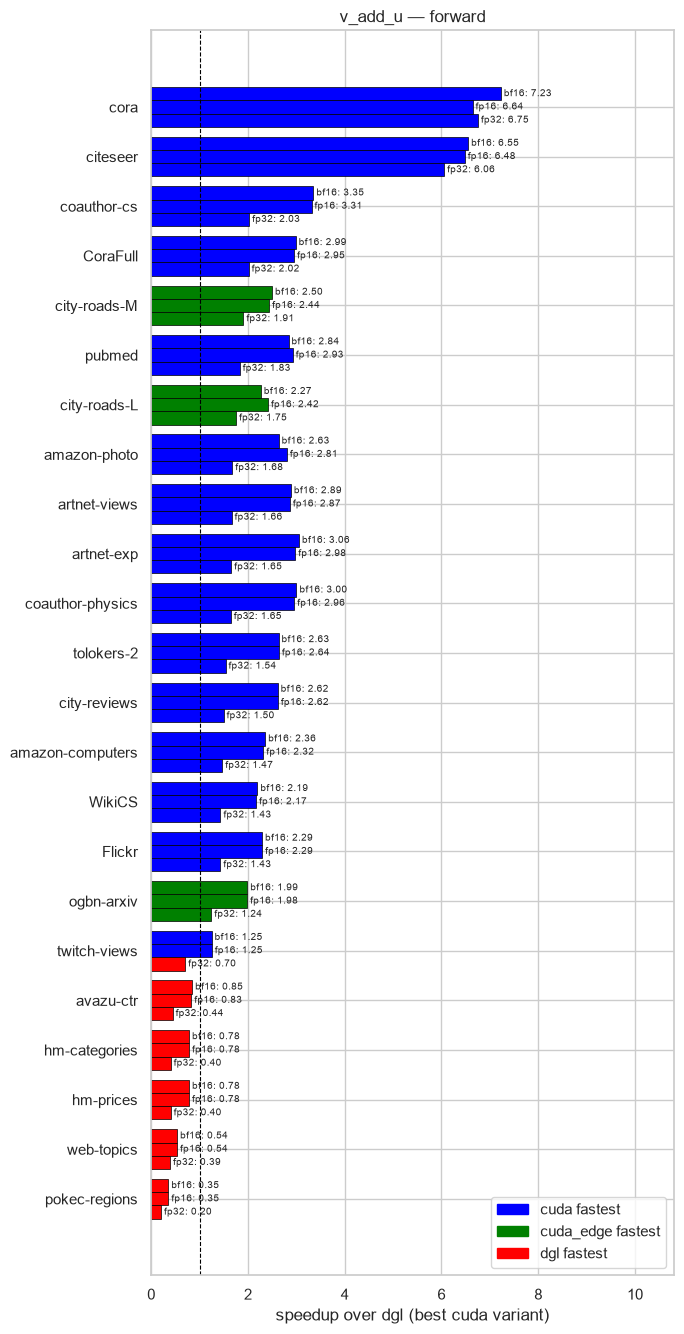

In [33]:
CONV = "v_add_u"

# best speedup over dgl among the cuda variants (>1 = faster than dgl); inf/0 come from the OOM masking above
df = result.xs(CONV, level="conv_type").reset_index()
df["speedup"] = df[["cuda_speedup", "cuda_edge_speedup"]].max(axis=1)

modes = [m for m in ("forward", "backward") if m in df["mode"].unique()]
# order datasets by their shortest bar (min speedup over dtypes/modes), descending from the top
shortest = df["speedup"].replace(np.inf, np.nan).groupby(df["dataset"]).min()
datasets = shortest.sort_values(ascending=False).index.tolist()
dtypes = sorted(df["dtype"].unique())

bar_h = 0.8 / len(dtypes)
y_base = np.arange(len(datasets))

fig, axes = plt.subplots(1, len(modes), figsize=(7 * len(modes), 0.5 * len(datasets) + 2), sharey=True, squeeze=False)

for ax, mode in zip(axes[0], modes):
    sub = df[df["mode"] == mode]
    finite = sub["speedup"].replace([np.inf, 0.0], np.nan)
    cap = finite.max() * 1.15  # where to draw the "infinitely better" bars

    for j, dtype in enumerate(dtypes):
        d = sub[sub["dtype"] == dtype].set_index("dataset").reindex(datasets)
        y = y_base - 0.4 + bar_h * (j + 0.5)
        vals = d["speedup"].replace(np.inf, cap).fillna(0.0).values
        ax.barh(y, vals, height=bar_h, color=d["color"].fillna("lightgray").values, edgecolor="black", linewidth=0.5)
        for yi, v, raw in zip(y, vals, d["speedup"].values):
            label = "∞" if np.isinf(raw) else ("OOM" if raw == 0.0 or np.isnan(raw) else f"{raw:.2f}")
            ax.text(v, yi, f" {dtype}: {label}", va="center", ha="left", fontsize=7)

    ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
    ax.set_yticks(y_base)
    ax.set_yticklabels(datasets)
    ax.invert_yaxis()  # first (largest min-speedup) dataset on top
    ax.set_xlim(0, cap * 1.3)
    ax.set_xlabel("speedup over dgl (best cuda variant)")
    ax.set_title(f"{CONV} — {mode}")

handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=f"{b} fastest") for b, c in BACKEND_COLORS.items()]
axes[0][0].legend(handles=handles, loc="lower right")
fig.tight_layout()
plt.show()
